
Predicted probabilities:

Atelectasis    : 0.1401
Cardiomegaly   : 0.0041
Effusion       : 0.3273
Infiltration   : 0.0770
Mass           : 0.7847
Nodule         : 0.1158
Pneumonia      : 0.0058
Pneumothorax   : 0.0498
Consolidation  : 0.0512
No Finding     : 0.1021

Disease:

Effusion: 0.3273
Mass: 0.7847


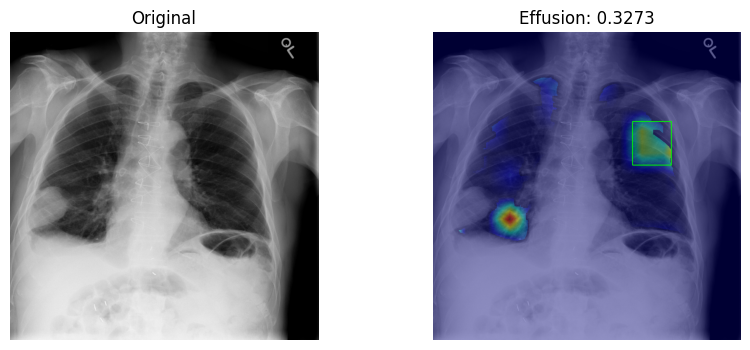

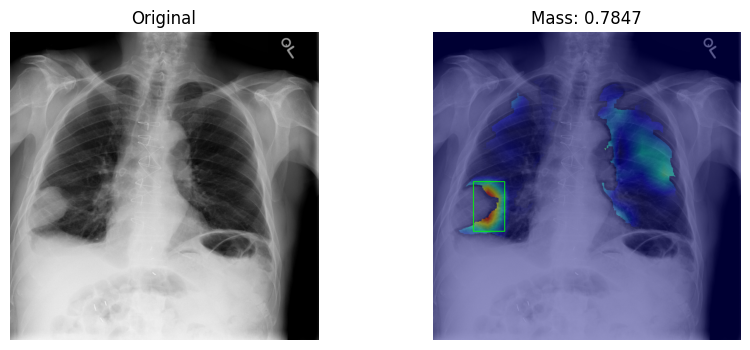

In [10]:
# ===============================
# 🔥 IMPORTS
# ===============================
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tkinter as tk
from tkinter import filedialog

# ===============================
# 🔥 CONFIG
# ===============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224

CLASSES = [
    "Atelectasis","Cardiomegaly","Effusion","Infiltration",
    "Mass","Nodule","Pneumonia","Pneumothorax",
    "Consolidation","No Finding"
]

# ===============================
# 🔥 MODEL
# ===============================
class EfficientNetXAI(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.efficientnet_b0(weights=None)
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1280, len(CLASSES))

    def forward(self, x):
        feat = self.features(x)
        pooled = self.pool(feat).flatten(1)
        out = self.classifier(pooled)
        return out, feat

model = EfficientNetXAI().to(DEVICE)
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()

# ===============================
# 🔥 TRANSFORM
# ===============================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ===============================
# 🔥 FILE PICKER
# ===============================
def select_file():
    root = tk.Tk()
    root.withdraw()
    return filedialog.askopenfilename()

# ===============================
# 🔥 LOAD IMAGE
# ===============================
def load_image(path):
    img = Image.open(path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    return img, tensor

# ===============================
# 🔥 RELAXED X-RAY CHECK
# ===============================
def is_chest_xray(img):
    img_np = np.array(img)

    # Convert to grayscale
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    # 1. Check grayscale nature (RELAXED)
    if len(img_np.shape) == 3:
        diff = np.abs(img_np[:,:,0] - img_np[:,:,1]).mean() + \
               np.abs(img_np[:,:,1] - img_np[:,:,2]).mean()

        if diff > 40:   # 🔥 increased threshold (was 15)
            return False

    # 2. Check brightness variation (X-rays have smooth gradients)
    if gray.std() < 10:
        return False

    # 3. Edge presence (RELAXED)
    edges = cv2.Canny(gray, 30, 120)

    if edges.mean() < 2:   # 🔥 reduced strictness (was 5)
        return False

    return True

# ===============================
# 🔥 GRADCAM++ (BEST)
# ===============================
class GradCAMPlusPlus:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        self.target_layer = self.model.features[5]

        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        self.model.zero_grad()

        logits, _ = self.model(x)
        score = torch.sigmoid(logits)[0, class_idx]

        score.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        grad_2 = gradients ** 2
        grad_3 = gradients ** 3

        eps = 1e-8
        alpha = grad_2 / (2 * grad_2 + torch.sum(activations * grad_3, dim=(1,2), keepdim=True) + eps)

        weights = torch.sum(alpha * torch.relu(gradients), dim=(1,2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam.detach().cpu().numpy()

        if cam.max() != 0:
            cam = cam / cam.max()

        return cam

# ===============================
# 🔥 LUNG MASK
# ===============================
def lung_mask(cam, orig_img):
    img = np.array(orig_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(2.0, (8,8))
    gray = clahe.apply(gray)

    _, thresh = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((9,9), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    mask = np.zeros_like(thresh)

    if contours:
        contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
        for c in contours:
            cv2.drawContours(mask, [c], -1, 255, -1)

    # 🔥 remove borders/wires
    mask = cv2.erode(mask, np.ones((15,15), np.uint8))

    mask = cv2.resize(mask, (cam.shape[1], cam.shape[0]))
    return cam * (mask / 255.0)

# ===============================
# 🔥 BOUNDING BOX
# ===============================
def get_bbox(cam, orig_img):
    cam_uint8 = np.uint8(255 * cam)

    # Strong threshold (remove weak noise)
    _, thresh = cv2.threshold(cam_uint8, 80, 255, cv2.THRESH_BINARY)

    # ===============================
    # 🔥 CREATE LUNG MASK
    # ===============================
    img = np.array(orig_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    _, lung = cv2.threshold(gray, 0, 255,
                            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((9,9), np.uint8)
    lung = cv2.morphologyEx(lung, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(lung, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    mask = np.zeros_like(lung)

    if contours:
        contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]
        for c in contours:
            cv2.drawContours(mask, [c], -1, 255, -1)

    # 🔥 REMOVE BORDER REGION (IMPORTANT)
    mask = cv2.erode(mask, np.ones((25,25), np.uint8))

    # ===============================
    # 🔥 APPLY MASK TO CAM
    # ===============================
    thresh = cv2.bitwise_and(thresh, mask)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    c = max(contours, key=cv2.contourArea)

    return cv2.boundingRect(c)

# ===============================
# 🔥 SHOW CAM
# ===============================
def show_cam(img, cam, title=""):
    img_np = np.array(img)

    cam = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    cam = lung_mask(cam, img)

    if cam.max() != 0:
        cam = cam / cam.max()

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    bbox = get_bbox(cam, img)
    if bbox:
        x, y, w, h = bbox
        cv2.rectangle(overlay, (x,y), (x+w,y+h), (0,255,0), 2)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title(title)
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

# ===============================
# 🔥 MAIN
# ===============================
img_path = select_file()

if img_path == "":
    print("❌ No file selected")

else:
    orig_img, img_tensor = load_image(img_path)

    if not is_chest_xray(orig_img):
        print("❌ Error: Not a Chest X-ray image. Please upload valid scan.")

    else:
        with torch.no_grad():
            logits, _ = model(img_tensor)

        probs = torch.sigmoid(logits)[0].cpu().numpy()
        cam_gen = GradCAMPlusPlus(model)
    
        no_idx = CLASSES.index("No Finding")
        no_prob = probs[no_idx]
    
        print("\nPredicted probabilities:\n")
        for i, p in enumerate(probs):
            print(f"{CLASSES[i]:15}: {p:.4f}")
    
        print("\nDisease:\n")
    
        detected = []
    
        if no_prob > 0.5:
            print(f"No Finding: {no_prob:.4f}")
            detected.append((no_idx, no_prob))
        else:
            for i, prob in enumerate(probs):
                if i != no_idx and prob > 0.275:
                    print(f"{CLASSES[i]}: {prob:.4f}")
                    detected.append((i, prob))
    
        if not detected:
            print("No disease detected")
    
        for idx, prob in detected:
            if CLASSES[idx] == "No Finding":
                continue   # 🔥 skip heatmap

            cam = cam_gen.generate(img_tensor, idx)
            show_cam(orig_img, cam, f"{CLASSES[idx]}: {prob:.4f}")